# DualSentinel — Skip Detectors + LLM Judge + Evaluation

Equivalente CLI:
```bash
python src/pipeline.py \
  --input "data/samples/LMD-2023 [1.75M Elements - Normal]checked.csv" \
  --dataset lmd \
  --skip-detectors \
  --threshold 0.2 \
  --evaluate
```

- **IsolationForest + GRU**: desligados (`--skip-detectors`) → `detector_score` é apenas do ATT&CK rule tagger (max 0.2)
- **SLM Analyst (Phi-3) + LLM Judge (Llama 3.1)**: ativos
- **Avaliação real**: ROC/AUC/F1 misturando o ficheiro normal com o LMD-2023 EoHT (ataque)

**Pré-requisitos:** Ollama em execução com `phi3:medium` e `llama3.1` (ou os modelos definidos em `SLM_MODEL` / `JUDGE_MODEL`).

## Configuração

In [5]:
import sys, os
from pathlib import Path
from datetime import datetime

# Localizar a raiz do DualSentinel independentemente de onde foi lançado o kernel
_cwd = Path.cwd()
_candidates = [
    _cwd,
    _cwd / 'DualSentinel',
    _cwd.parent,
    _cwd.parent / 'DualSentinel',
]
_root = next((p.resolve() for p in _candidates if (p / 'src' / 'pipeline.py').exists()), _cwd)
_src = _root / 'src'
sys.path.insert(0, str(_src))
os.chdir(_root)

import json, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

# ── Parâmetros (espelham as flags do CLI) ─────────────────────────────────
INPUT_PATH        = Path('data/samples/LMD-2023 [1.75M Elements - Normal]checked.csv')
ATTACK_PATH       = Path('data/samples/LMD-2023 [2.3M Elements - EoHT]checked.csv')
DATASET           = 'lmd'
SKIP_DETECTORS    = True       # --skip-detectors
THRESHOLD         = 0.2        # --threshold 0.2
EVALUATE          = True       # --evaluate
MAX_ROWS          = 150_000    # cap p/ corrida rápida; põe None p/ ficheiro completo
MAX_JUDGE_WINDOWS = 50
WINDOW_SECONDS    = 60
MAX_EVENTS_PER_WINDOW = 200

# Modelos Ollama (sobrepõem .env se definido fora do notebook)
SLM_MODEL   = os.environ.setdefault('SLM_MODEL',   'phi3:medium')
JUDGE_MODEL = os.environ.setdefault('JUDGE_MODEL', 'llama3.1')

RUN_TS     = datetime.now().strftime('%Y-%m-%d_%H-%M')
OUTPUT_DIR = Path('results') / f'{RUN_TS}_skiprules_eval'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Working dir   : {Path.cwd()}')
print(f'Input exists  : {INPUT_PATH.exists()}  ({INPUT_PATH.name})')
print(f'Attack exists : {ATTACK_PATH.exists()}  ({ATTACK_PATH.name})')
print(f'Output dir    : {OUTPUT_DIR}')
print(f'Models        : SLM={SLM_MODEL}  Judge={JUDGE_MODEL}')
print(f'Mode          : skip_detectors={SKIP_DETECTORS}  threshold={THRESHOLD}  evaluate={EVALUATE}  max_rows={MAX_ROWS}')

Working dir   : D:\ISEP\Challange-3\DualSentinel
Input exists  : True  (LMD-2023 [1.75M Elements - Normal]checked.csv)
Attack exists : True  (LMD-2023 [2.3M Elements - EoHT]checked.csv)
Output dir    : results\2026-04-19_22-31_skiprules_eval
Models        : SLM=phi3:medium  Judge=llama3.1
Mode          : skip_detectors=True  threshold=0.2  evaluate=True  max_rows=150000


## Pre-flight — Ollama
Verifica que ambos os modelos estão pulled antes de gastar tempo a fazer parsing.

In [6]:
import ollama

_models = sorted({m.model for m in ollama.list().models})
_aliases = {}

for model_name in _models:
    _aliases.setdefault(model_name, model_name)
    _aliases.setdefault(model_name.split(':')[0], model_name)

def _family(name):
    return name.split(':')[0].split('.')[0]

def _resolve_model(requested):
    if requested in _aliases:
        return _aliases[requested]

    candidates = [m for m in _models if _family(m) == _family(requested)]
    if candidates:
        return candidates[-1]

    return None

print('Modelos disponíveis:')
for name in _models:
    print(f'  ✓ {name}')

_missing = []
for label, requested in (('SLM_MODEL', SLM_MODEL), ('JUDGE_MODEL', JUDGE_MODEL)):
    resolved = _resolve_model(requested)
    if resolved is None:
        _missing.append((label, requested))
        continue

    if resolved != requested:
        print(f'\n! {label}={requested!r} não encontrado; a usar {resolved!r}.')
        globals()[label] = resolved

if _missing:
    for label, requested in _missing:
        print(f'\n✗ {label}={requested!r} — em falta. Corre:  ollama pull {requested}')
    raise RuntimeError(f'Modelos em falta: {[m for _, m in _missing]}')
else:
    print(f'\n✓ {SLM_MODEL!r} e {JUDGE_MODEL!r} prontos.')

INFO httpx: HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"


Modelos disponíveis:
  ✓ llama3.2:latest
  ✓ phi3:medium
  ✓ phi3:mini
  ✓ phi4:14b
  ✓ qwen3:8b

! JUDGE_MODEL='llama3.1' não encontrado; a usar 'llama3.2:latest'.

✓ 'phi3:medium' e 'llama3.2:latest' prontos.


## Step 1 — Parse + Windowing
Carrega o CSV normal, extrai 60s windows e calcula o vector de features.

In [7]:
from preprocessor import parse_csv, make_windows

df = parse_csv(INPUT_PATH, dataset=DATASET, nrows=MAX_ROWS)
print(f'Eventos carregados : {len(df):,}')
print(f'Time range         : {df.timestamp.min()}  →  {df.timestamp.max()}')
print(f'Unique EventIDs    : {sorted(df.event_id.unique())}')

windows = list(make_windows(df, window_size_seconds=WINDOW_SECONDS, max_events=MAX_EVENTS_PER_WINDOW))
wdf = pd.DataFrame([w.to_dict() for w in windows])
print(f'Janelas criadas    : {len(windows)}')
df.head()

INFO preprocessor: Loaded 62675 events from LMD-2023 [1.75M Elements - Normal]checked.csv (dataset=lmd)


Eventos carregados : 62,675
Time range         : 2026-04-19 00:00:06+00:00  →  2026-04-19 23:59:54+00:00
Unique EventIDs    : [np.int64(1), np.int64(3), np.int64(5), np.int64(6), np.int64(8), np.int64(11), np.int64(12), np.int64(13), np.int64(15), np.int64(22)]
Janelas criadas    : 1424


,unnamed: 0,label,name,guid,event_id,version,level,task,opcode,keywords,...,sourceprocessguid,targetprocessguid,newthreadid,startaddress,startmodule,startfunction,previouscreationutctime,hash,contents,id
0,7132,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,3,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
1,25965,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},22,5,4,22,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
2,25964,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},22,5,4,22,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
3,3248,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,3,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0
4,80242,0,Microsoft-Windows-Sysmon,{5770385f-c22a-43e0-bf4c-06f5698ffbd9},1,5,4,1,0,0x8000000000000000,...,0,0,0.0,0,0,0,0,0,0,0


## Step 2 — Skip Detectors + ATT&CK Rule Tagger
`if_score = gru_score = 0`. O `detector_score` final vem só do rule tagger (`ensemble_score(0, 0, has_hits)` → 0.0 ou 0.2).

Janelas ≥ threshold (0.2): 462/1424
Saved → results\2026-04-19_22-31_skiprules_eval\windows_scored.json


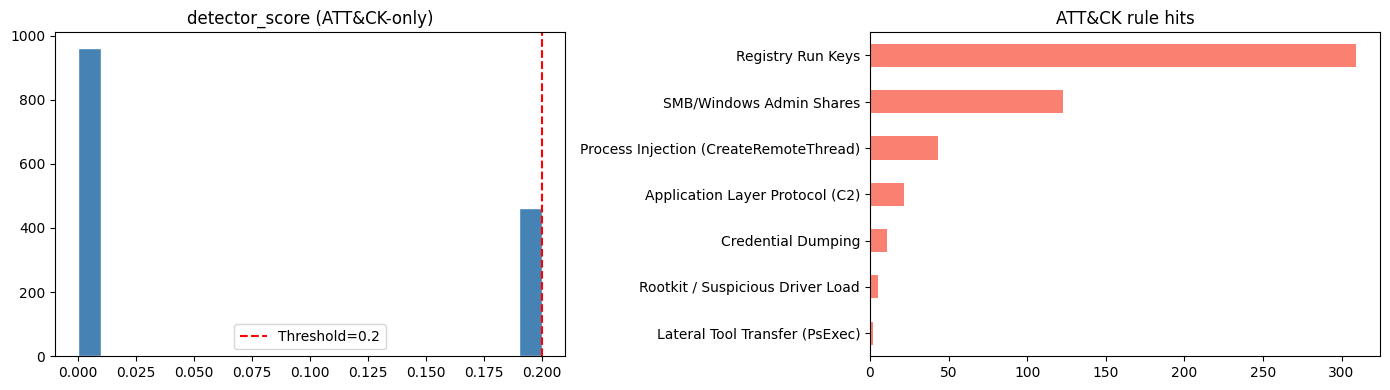

In [8]:
from detectors import tag_techniques, ensemble_score

if_scores  = np.zeros(len(windows))
gru_scores = np.zeros(len(windows))

window_dicts = []
for i, w in enumerate(windows):
    wd = w.to_dict()
    wd['attck_hits']     = tag_techniques(wd)
    wd['if_score']       = float(if_scores[i])
    wd['gru_score']      = float(gru_scores[i])
    wd['detector_score'] = ensemble_score(0.0, 0.0, len(wd['attck_hits']) > 0)
    window_dicts.append(wd)

wdf['detector_score']  = [w['detector_score'] for w in window_dicts]
wdf['attck_hit_count'] = [len(w['attck_hits']) for w in window_dicts]

ws_path = OUTPUT_DIR / 'windows_scored.json'
with open(ws_path, 'w') as f:
    json.dump(window_dicts, f, indent=2, default=str)

high_risk = sum(1 for w in window_dicts if w['detector_score'] >= THRESHOLD)
print(f'Janelas ≥ threshold ({THRESHOLD}): {high_risk}/{len(window_dicts)}')
print(f'Saved → {ws_path}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(wdf['detector_score'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold={THRESHOLD}')
axes[0].set_title('detector_score (ATT&CK-only)'); axes[0].legend()

from collections import Counter
tech_counts = Counter(h['name'] for w in window_dicts for h in w['attck_hits'])
if tech_counts:
    pd.Series(tech_counts).sort_values().plot(kind='barh', ax=axes[1], color='salmon',
                                              title='ATT&CK rule hits')
else:
    axes[1].text(0.5, 0.5, 'No ATT&CK rule hits', ha='center', va='center')
    axes[1].set_title('ATT&CK rule hits')
plt.tight_layout(); plt.show()

## Step 3 — SLM Analyst (Phi-3)
Triagem rápida sobre janelas acima do threshold. Pré-filtro evita chamadas Ollama em janelas trivialmente benignas.

In [ ]:
from slm_analyst import SLMAnalyst

analyst      = SLMAnalyst(model=SLM_MODEL)
slm_analyses = analyst.analyse_batch(window_dicts, threshold=THRESHOLD)

slm_path = OUTPUT_DIR / 'slm_analyses.json'
with open(slm_path, 'w') as f:
    json.dump([a.to_dict() for a in slm_analyses], f, indent=2, default=str)

sdf = pd.DataFrame([a.to_dict() for a in slm_analyses])
prefiltered = sdf['summary'].str.contains('pre-filter', na=False).sum() if not sdf.empty else 0
print(f'SLM analyses: {len(sdf)}  (pre-filtered: {prefiltered}, Ollama calls: {len(sdf) - prefiltered})')
print(f'Saved → {slm_path}')
if not sdf.empty:
    cols = [c for c in ('window_start','pre_score','risk_level','needs_deep_analysis','summary') if c in sdf.columns]
    sdf[cols].sort_values('pre_score', ascending=False).head(15)

INFO httpx: HTTP Request: GET http://127.0.0.1:11434/api/tags "HTTP/1.1 200 OK"
INFO slm_analyst: SLM analyst: 462/1424 janelas acima do threshold (0.2)
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http://127.0.0.1:11434/api/chat "HTTP/1.1 200 OK"
INFO httpx: HTTP Request: POST http:/

## Step 4 — LLM Judge (Llama 3.1)
Valida o pré-diagnóstico do Phi-3 com o evidence pack completo. Limitado a `MAX_JUDGE_WINDOWS`.

In [ ]:
from llm_judge import LLMJudge

judge = LLMJudge(model=JUDGE_MODEL)
judge_results = judge.judge_batch(
    window_dicts,
    slm_analyses=slm_analyses,
    threshold=THRESHOLD,
    max_windows=MAX_JUDGE_WINDOWS,
)

judge_path = OUTPUT_DIR / 'judge_results.json'
with open(judge_path, 'w') as f:
    json.dump([r.to_dict() for r in judge_results], f, indent=2, default=str)
print(f'Judge results: {len(judge_results)}')
print(f'Saved → {judge_path}')

if judge_results:
    jdf = pd.DataFrame([r.to_dict() for r in judge_results])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    verdict_colors = {'normal':'green','suspicious':'orange','malicious':'red','mildly suspicious':'gold'}
    vc = jdf['verdict'].value_counts()
    vc.plot(kind='bar', ax=axes[0],
            color=[verdict_colors.get(v,'grey') for v in vc.index],
            title='Verdict distribution')
    axes[1].hist(jdf['anomaly_score'], bins=range(12), color='steelblue', edgecolor='white')
    axes[1].axvline(7, color='red', linestyle='--', label='High-risk (≥7)')
    axes[1].set_title('anomaly_score'); axes[1].legend()
    plt.tight_layout(); plt.show()

    cols = [c for c in ('window_start','anomaly_score','verdict','slm_pre_score','detector_score','fp_risk') if c in jdf.columns]
    jdf[cols].sort_values('anomaly_score', ascending=False).head(20)
else:
    print('Nenhuma janela passou para o Judge.')

## Step 5 — Report Markdown
Mesmo output que o CLI (`results/.../report_*.md`).

In [ ]:
from pipeline import generate_report

report_path = generate_report(window_dicts, judge_results, OUTPUT_DIR, DATASET)
print(f'Report saved → {report_path}\n')
text = report_path.read_text(encoding='utf-8')
print(text[:3000])
if len(text) > 3000:
    print(f'\n... (truncado — completo em {report_path})')

## Step 6 — Avaliação real (`--evaluate`)

O `--evaluate` interno do pipeline só imprime aviso porque o ficheiro `[Normal]` não tem labels positivas. Aqui pontuamos um ficheiro de **ataque** (LMD-2023 EoHT) com a mesma lógica e calculamos AUC / F1 / Precision / Recall.

> **Nota:** com `SKIP_DETECTORS=True` o sinal vem só do ATT&CK rule tagger (0.0 ou 0.2). A AUC mede a qualidade da cobertura de regras, não os modelos ML. Para AUC completa, desliga `SKIP_DETECTORS` e re-corre desde o Step 1.

In [ ]:
from sklearn.metrics import (roc_auc_score, roc_curve, f1_score,
                             precision_score, recall_score, confusion_matrix)

if not EVALUATE:
    print('EVALUATE=False — skipping.')
elif not ATTACK_PATH.exists():
    print(f'[SKIP] {ATTACK_PATH.name} não encontrado — coloca em data/samples/ e re-corre.')
else:
    print(f'Parsing {ATTACK_PATH.name} (primeiras {MAX_ROWS:,} linhas) …', flush=True)
    df_att   = parse_csv(ATTACK_PATH, dataset='lmd', nrows=MAX_ROWS)
    wins_att = list(make_windows(df_att, window_size_seconds=WINDOW_SECONDS,
                                 max_events=MAX_EVENTS_PER_WINDOW))
    print(f'  → {len(df_att):,} eventos, {len(wins_att)} janelas')

    att_scores = np.array([
        ensemble_score(0.0, 0.0, len(tag_techniques(w.to_dict())) > 0)
        for w in wins_att
    ])
    norm_scores = np.array([w['detector_score'] for w in window_dicts])

    y_true  = np.concatenate([np.zeros(len(norm_scores)), np.ones(len(att_scores))])
    y_score = np.concatenate([norm_scores, att_scores])

    auc = roc_auc_score(y_true, y_score)
    fpr_c, tpr_c, _ = roc_curve(y_true, y_score)

    best_f1, best_thr = 0.0, THRESHOLD
    for thr in np.linspace(0.0, 1.0, 201):
        f = f1_score(y_true, (y_score >= thr).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_thr = f, thr

    y_pred = (y_score >= best_thr).astype(int)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    cm     = confusion_matrix(y_true, y_pred)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
    axes[0].plot(fpr_c, tpr_c, lw=2, color='steelblue', label=f'AUC = {auc:.4f}')
    axes[0].plot([0,1], [0,1], '--', color='grey', lw=0.8)
    axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
    axes[0].set_title('ROC — Normal vs EoHT'); axes[0].legend()

    norm_pct = (norm_scores >= best_thr).mean() * 100
    att_pct  = (att_scores  >= best_thr).mean() * 100
    bars = axes[1].bar(['Normal\n(Label=0)', 'EoHT\n(Label=1)'],
                       [norm_pct, att_pct], color=['#2ecc71','#e74c3c'], width=0.5)
    for b, v in zip(bars, [norm_pct, att_pct]):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+1, f'{v:.1f}%',
                     ha='center', fontweight='bold')
    axes[1].set_title(f'Detection rate @ thr={best_thr:.2f}')
    axes[1].set_ylim(0, 110); axes[1].set_ylabel('%')

    im = axes[2].imshow(cm, cmap='Blues')
    axes[2].set_xticks([0,1]); axes[2].set_xticklabels(['Pred N','Pred A'])
    axes[2].set_yticks([0,1]); axes[2].set_yticklabels(['Act N','Act A'])
    for i in range(2):
        for j in range(2):
            axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                         color='white' if cm[i,j] > cm.max()/2 else 'black')
    axes[2].set_title(f'Confusion matrix @ thr={best_thr:.2f}')
    plt.colorbar(im, ax=axes[2])
    plt.suptitle('DualSentinel — Skip Detectors evaluation (ATT&CK rule signal)', y=1.02)
    plt.tight_layout(); plt.show()

    print(f'\n{"="*55}')
    print(f'  Normal windows : {len(norm_scores):>6,}')
    print(f'  Attack windows : {len(att_scores):>6,}')
    print(f'  AUC-ROC        : {auc:.4f}')
    print(f'  Best threshold : {best_thr:.2f}')
    print(f'  Precision      : {prec:.4f}')
    print(f'  Recall         : {rec:.4f}')
    print(f'  F1-score       : {best_f1:.4f}')
    print(f'  @ thr={THRESHOLD}: FPR={(norm_scores>=THRESHOLD).mean():.3f}  TPR={(att_scores>=THRESHOLD).mean():.3f}')
    print(f'{"="*55}')

## Run Summary

In [ ]:
malicious  = [r for r in judge_results if r.verdict == 'malicious']
suspicious = [r for r in judge_results if r.verdict in ('suspicious','mildly suspicious')]
normal     = [r for r in judge_results if r.verdict == 'normal']

print('=' * 50)
print('PIPELINE RUN SUMMARY  (skip_detectors + judge ON + evaluate)')
print('=' * 50)
print(f'Input          : {INPUT_PATH.name}')
print(f'Output dir     : {OUTPUT_DIR}')
print(f'Events parsed  : {len(df):,}')
print(f'Windows        : {len(windows):,}')
print(f'Threshold      : {THRESHOLD}')
print(f'SLM calls      : {len(sdf) - prefiltered}  ({prefiltered} pre-filtered)')
print(f'Judge calls    : {len(judge_results)}')
print(f'  Malicious    : {len(malicious)}')
print(f'  Suspicious   : {len(suspicious)}')
print(f'  Normal       : {len(normal)}')
print(f'Report         : {report_path}')
print('=' * 50)